<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/ESAA_YB_WEEK3_study_0316_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#새로운 전처리/시각화 분석결과

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()

%matplotlib inline

pd.options.mode.chained_assignment = None # default = 'warn'

In [5]:
#구글 드라이브 마운트(연결)
from google.colab import drive
drive.mount('/content/drive')

# 해당 폴더 안의 파일 목록 출력
from subprocess import check_output

# 실제 드라이브 경로
folder_path = '/content/drive/MyDrive/26-1/ESAA/[ESAA] WEEK3/Instacart dataset'
print(check_output(["ls", folder_path]).decode("utf8"))

Mounted at /content/drive
aisles.csv
departments.csv
order_products__prior.csv
order_products__train.csv
orders.csv
products.csv
sample_submission.csv



/tmp/ipykernel_524/3601075354.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='reordered', y='department', data=dept_reorder_df, palette='viridis')


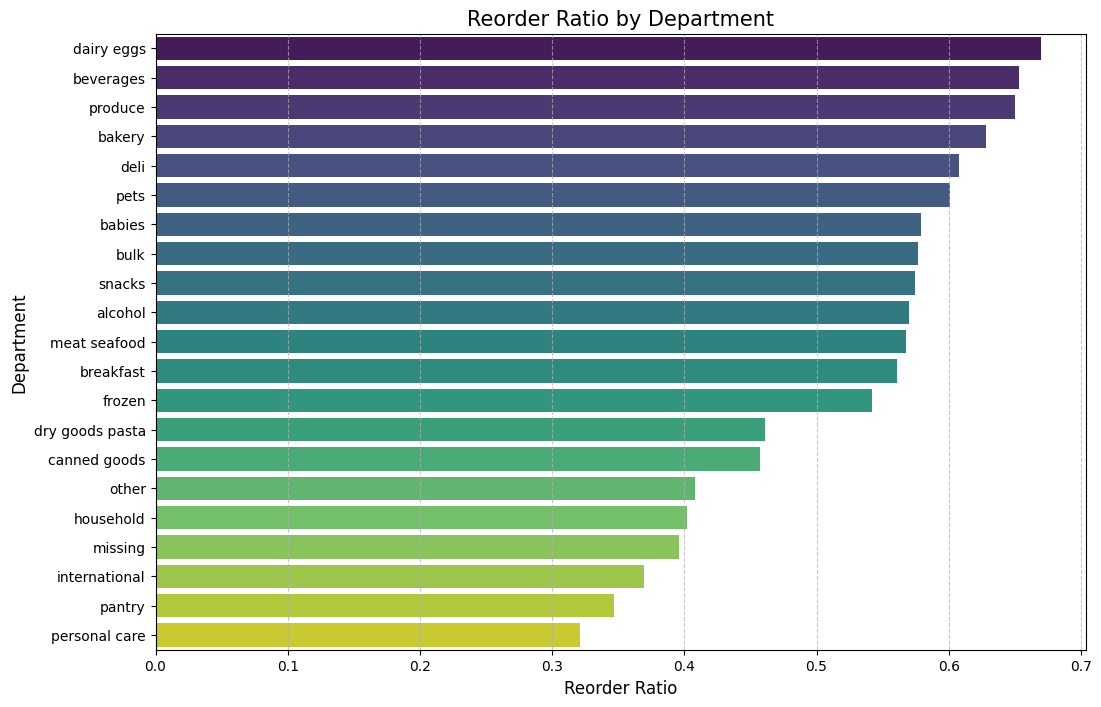

In [6]:
path = '/content/drive/MyDrive/26-1/ESAA/[ESAA] WEEK3/Instacart dataset/'
order_products_prior_df = pd.read_csv(path + 'order_products__prior.csv')
products_df = pd.read_csv(path + 'products.csv')
departments_df = pd.read_csv(path + 'departments.csv')

# 전처리: 병합
merged_df = pd.merge(order_products_prior_df, products_df, on='product_id', how='left')
merged_df = pd.merge(merged_df, departments_df, on='department_id', how='left')

# 전처리: 부서별 재구매율 계산 및 정렬
dept_reorder_df = merged_df.groupby('department')['reordered'].mean().reset_index()
dept_reorder_df = dept_reorder_df.sort_values(by='reordered', ascending=False)

# 시각화: 부서별 재구매율 가로 막대 그래프
plt.figure(figsize=(12, 8))
sns.barplot(x='reordered', y='department', data=dept_reorder_df, palette='viridis')

plt.title('Reorder Ratio by Department', fontsize=15)
plt.xlabel('Reorder Ratio', fontsize=12)
plt.ylabel('Department', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

- 우유/계란(dairy eggs), 음료(beverages), 과일/채소(produce) 등 일상생활에서 주기적으로 소비하는 신선식품 및 생필품 카테고리의 재구매율이 가장 높게 나타났다.

- 반면, 향신료/양념(pantry), 구급약/개인위생용품(personal care) 카테고리는 한 번 구매하면 오래 사용하거나 필요할 때만 가끔 구매하는 특성이 있어 상대적으로 재구매율이 낮았다.

=> Instacart 고객들은 쟁여두고 쓰는 물품보다는, 매주/매일 신선하게 소비해야 하는 일상 식료품을 위주로 이 서비스를 반복 이용하고 있다는 것을 알 수 있다.